<a href="https://colab.research.google.com/github/ervatoker/IOT-Erva-Toker/blob/main/TabNSA_TONIoT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CONFIG

DRIVE_DATASET = "/content/drive/MyDrive/datasets/toniot_arnob_dataset"
DRIVE_OUT_DIR = "/content/drive/MyDrive/toniot_outputs"

LABEL_COL   = "type"
RANDOM_SEED = 42
TEST_SIZE   = 0.2
VAL_SIZE    = 0.1

# TabNSA settings
DEVICE     = "cuda"
N_EPOCHS   = 100
BATCH_SIZE = 512
LR         = 1e-3
D_MODEL    = 128
N_HEADS    = 4
DEPTH      = 2
DROPOUT    = 0.1
TOP_K      = 8
WINDOW     = 5
PATIENCE   = 15

print("Config loaded.")

Config loaded.


In [2]:
# INSTALL

!pip install -q scikit-learn pandas numpy matplotlib seaborn

print("All packages installed.")

All packages installed.


In [3]:
# IMPORTS + DRIVE MOUNT + GPU CHECK

import os, glob, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix,
    precision_score, recall_score,
    roc_auc_score, cohen_kappa_score,
    matthews_corrcoef, roc_curve, auc
)

from google.colab import drive
drive.mount("/content/drive")
os.makedirs(DRIVE_OUT_DIR, exist_ok=True)

if not torch.cuda.is_available():
    print("WARNING: No GPU detected.")
    DEVICE = "cpu"
else:
    print(f"GPU confirmed : {torch.cuda.get_device_name(0)}")
    print(f"VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"Device        : {DEVICE}")

Mounted at /content/drive
GPU confirmed : Tesla T4
VRAM          : 15.6 GB
Device        : cuda


In [4]:
# LOAD DATA

csv_files = glob.glob(os.path.join(DRIVE_DATASET, "**/*.csv"), recursive=True)
print(f"Found {len(csv_files)} CSV files")

dfs = []
for f in csv_files:
    try:
        dfs.append(pd.read_csv(f, low_memory=False))
    except Exception as e:
        print(f"  Skipped {f}: {e}")

df = pd.concat(dfs, ignore_index=True)
print(f"Total rows   : {len(df):,}")
print(f"Total columns: {df.shape[1]}")
print(f"\nLabel distribution:\n{df[LABEL_COL].value_counts()}")

Found 1 CSV files
Total rows   : 211,043
Total columns: 44

Label distribution:
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043
Name: count, dtype: int64


In [5]:
# PREPROCESS

drop_cols = [LABEL_COL]
for col in ["ts", "src_ip", "dst_ip", "src_mac", "dst_mac"]:
    if col in df.columns:
        drop_cols.append(col)

X = df.drop(columns=drop_cols)
y_raw = df[LABEL_COL]

le = LabelEncoder()
y = le.fit_transform(y_raw)
num_classes = len(le.classes_)
print(f"Classes ({num_classes}): {list(le.classes_)}")

X = X.select_dtypes(include=[np.number])
X = X.replace([np.inf, -np.inf], np.nan)
print(f"Features     : {X.shape[1]}")

X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=RANDOM_SEED, stratify=y_tv)

print(f"\nTrain : {len(X_train):,}")
print(f"Val   : {len(X_val):,}")
print(f"Test  : {len(X_test):,}")

train_median = X_train.median()
X_train = X_train.fillna(train_median)
X_val   = X_val.fillna(train_median)
X_test  = X_test.fillna(train_median)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

n_features = X_train_s.shape[1]
print(f"\nFeatures after preprocessing : {n_features}")
print("Preprocessing complete — no data leakage")

Classes (10): ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']
Features     : 17

Train : 147,729
Val   : 21,105
Test  : 42,209

Features after preprocessing : 17
Preprocessing complete — no data leakage


In [6]:
# EVALUATION HELPER

def evaluate(model_name, y_true, y_pred, label_names, out_dir):
    acc         = accuracy_score(y_true, y_pred)
    f1_macro    = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n{'='*55}")
    print(f"  {model_name} — Results")
    print(f"{'='*55}")
    print(f"  Accuracy      : {acc:.4f}")
    print(f"  F1 (macro)    : {f1_macro:.4f}")
    print(f"  F1 (weighted) : {f1_weighted:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=label_names, zero_division=0)}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout()
    path = os.path.join(out_dir, f"{model_name.lower().replace(' ', '_')}_cm.png")
    plt.savefig(path, dpi=150); plt.show()
    print(f"Saved: {path}")

    return {"model": model_name, "accuracy": acc,
            "f1_macro": f1_macro, "f1_weighted": f1_weighted}

print("Evaluation helper ready.")

Evaluation helper ready.


In [7]:
# TabNSA MODEL DEFINITION


class FeatureEmbedding(nn.Module):
    def __init__(self, n_features, d_model):
        super().__init__()
        self.proj = nn.Linear(1, d_model)
        self.bias = nn.Parameter(torch.zeros(n_features, d_model))

    def forward(self, x):
        # x: (B, F) -> (B, F, D)
        return self.proj(x.unsqueeze(-1)) + self.bias.unsqueeze(0)


class TokenCompression(nn.Module):

    def __init__(self, d_model, compress_ratio=2):
        super().__init__()
        self.pool = nn.AvgPool1d(kernel_size=compress_ratio, stride=compress_ratio)
        self.proj = nn.Linear(d_model, d_model)

    def forward(self, x):
        # x: (B, F, D) -> (B, F//ratio, D)
        out = self.pool(x.transpose(1, 2)).transpose(1, 2)
        return self.proj(out)


class SelectivePreservation(nn.Module):

    def __init__(self, d_model, top_k=8):
        super().__init__()
        self.top_k = top_k
        self.gate = nn.Linear(d_model, 1)

    def forward(self, x):
        # x: (B, F, D) -> scores per token
        scores = self.gate(x).squeeze(-1)  # (B, F)
        k = min(self.top_k, x.size(1))
        topk_idx = scores.topk(k, dim=-1).indices  # (B, k)
        # Gather top-k tokens
        topk_idx_exp = topk_idx.unsqueeze(-1).expand(-1, -1, x.size(-1))
        selected = x.gather(1, topk_idx_exp)  # (B, k, D)
        return selected, scores


class SlidingWindowAttention(nn.Module):

    def __init__(self, d_model, n_heads, window_size=5, dropout=0.1):
        super().__init__()
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.window = window_size
        self.W_qkv = nn.Linear(d_model, 3 * d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        self.scale = self.d_head ** -0.5

    def forward(self, x):
        B, N, D = x.shape
        qkv = self.W_qkv(x).reshape(B, N, 3, self.n_heads, self.d_head)
        q, k, v = qkv.unbind(dim=2)
        q = q.transpose(1, 2)  # (B, H, N, d)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)

        # Create sliding window mask
        mask = torch.ones(N, N, device=x.device, dtype=torch.bool)
        for i in range(N):
            lo = max(0, i - self.window // 2)
            hi = min(N, i + self.window // 2 + 1)
            mask[i, lo:hi] = False
        # True = masked out
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.masked_fill(mask.unsqueeze(0).unsqueeze(0), float('-inf'))
        attn = self.dropout(F.softmax(attn, dim=-1))
        out = (attn @ v).transpose(1, 2).reshape(B, N, D)
        return self.W_o(out)


class TabMixerBlock(nn.Module):

    def __init__(self, n_tokens, d_model, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        # Token mixing (across features)
        self.token_mix = nn.Sequential(
            nn.Linear(n_tokens, n_tokens * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(n_tokens * 2, n_tokens),
        )
        # Channel mixing (within each feature)
        self.channel_mix = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
        )

    def forward(self, x):
        # Token mixing: (B, F, D) -> transpose -> mix across F
        res = x
        x = self.norm1(x)
        x = x.transpose(1, 2)  # (B, D, F)
        x = self.token_mix(x)
        x = x.transpose(1, 2)  # (B, F, D)
        x = x + res

        # Channel mixing
        res = x
        x = self.norm2(x)
        x = self.channel_mix(x)
        x = x + res
        return x


class NSABlock(nn.Module):

    def __init__(self, n_features, d_model, n_heads, top_k, window, dropout):
        super().__init__()
        self.compress = TokenCompression(d_model, compress_ratio=2)
        self.select   = SelectivePreservation(d_model, top_k=top_k)
        self.local_attn = SlidingWindowAttention(d_model, n_heads, window, dropout)
        self.norm = nn.LayerNorm(d_model)

        # Fusion: combine compressed + selected + local
        self.fusion = nn.Linear(d_model * 3, d_model)
        self.mixer  = TabMixerBlock(n_features, d_model, dropout)

    def forward(self, x):
        B, F, D = x.shape

        # Branch 1: Compressed global context
        compressed = self.compress(x)              # (B, F//2, D)
        comp_pool  = compressed.mean(dim=1)        # (B, D)

        # Branch 2: Selected top-k features
        selected, scores = self.select(x)          # (B, k, D)
        sel_pool = selected.mean(dim=1)            # (B, D)

        # Branch 3: Local sliding window attention
        local = self.local_attn(x)                 # (B, F, D)
        local_pool = local.mean(dim=1)             # (B, D)

        # Fuse all three branches
        fused = self.fusion(torch.cat([comp_pool, sel_pool, local_pool], dim=-1))
        fused = fused.unsqueeze(1).expand(-1, F, -1)  # broadcast to (B, F, D)

        x = self.norm(x + fused)
        x = self.mixer(x)
        return x


class TabNSA(nn.Module):
    def __init__(self, n_features, num_classes, d_model=128, n_heads=4,
                 depth=2, top_k=8, window=5, dropout=0.1):
        super().__init__()
        self.embedding = FeatureEmbedding(n_features, d_model)

        self.blocks = nn.ModuleList([
            NSABlock(n_features, d_model, n_heads, top_k, window, dropout)
            for _ in range(depth)
        ])

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, x):
        x = self.embedding(x)          # (B, F, D)
        for block in self.blocks:
            x = block(x)
        x = x.mean(dim=1)              # global pool -> (B, D)
        return self.head(x)

params = sum(p.numel() for p in TabNSA(
    n_features, num_classes, D_MODEL, N_HEADS,
    DEPTH, TOP_K, WINDOW, DROPOUT).parameters())
print(f"TabNSA params: {params:,}")
print("Model class ready.")

TabNSA params: 551,802
Model class ready.


In [8]:
# TabNSA TRAINING

model = TabNSA(
    n_features=n_features, num_classes=num_classes,
    d_model=D_MODEL, n_heads=N_HEADS, depth=DEPTH,
    top_k=TOP_K, window=WINDOW, dropout=DROPOUT,
).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
criterion = nn.CrossEntropyLoss()

train_ds = TensorDataset(torch.tensor(X_train_s), torch.tensor(y_train, dtype=torch.long))
val_ds   = TensorDataset(torch.tensor(X_val_s),   torch.tensor(y_val, dtype=torch.long))
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

print("Training TabNSA on TON-IoT...")
print(f"Config: d_model={D_MODEL}, depth={DEPTH}, heads={N_HEADS}, "
      f"top_k={TOP_K}, window={WINDOW}, lr={LR}")
print()

t0 = time.time()
best_val_f1 = 0
best_state  = None
no_improve  = 0

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    epoch_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()

    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in val_dl:
            preds = model(xb.to(DEVICE)).argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds); all_true.extend(yb.numpy())

    val_acc = accuracy_score(all_true, all_preds)
    val_f1  = f1_score(all_true, all_preds, average="macro", zero_division=0)

    print(f"  Epoch {epoch:03d}/{N_EPOCHS} | "
          f"Loss: {epoch_loss/len(train_dl):.4f} | "
          f"Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
    if no_improve >= PATIENCE:
        print(f"  Early stopping at epoch {epoch} (best Val F1: {best_val_f1:.4f})")
        break

model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
model.eval()
train_time = time.time() - t0
print(f"\nBest Val F1: {best_val_f1:.4f}")
print(f"TabNSA training complete in {train_time:.1f}s ({train_time/60:.1f} min)")

Training TabNSA on TON-IoT...
Config: d_model=128, depth=2, heads=4, top_k=8, window=5, lr=0.001

  Epoch 001/100 | Loss: 1.1315 | Val Acc: 0.5858 | Val F1: 0.4221
  Epoch 002/100 | Loss: 0.7335 | Val Acc: 0.7535 | Val F1: 0.6224
  Epoch 003/100 | Loss: 0.5846 | Val Acc: 0.7605 | Val F1: 0.6408
  Epoch 004/100 | Loss: 0.5265 | Val Acc: 0.8339 | Val F1: 0.7253
  Epoch 005/100 | Loss: 0.4615 | Val Acc: 0.8618 | Val F1: 0.7700
  Epoch 006/100 | Loss: 0.3910 | Val Acc: 0.9043 | Val F1: 0.8151
  Epoch 007/100 | Loss: 0.3314 | Val Acc: 0.8712 | Val F1: 0.7816
  Epoch 008/100 | Loss: 0.3063 | Val Acc: 0.9061 | Val F1: 0.8295
  Epoch 009/100 | Loss: 0.2930 | Val Acc: 0.9316 | Val F1: 0.8629
  Epoch 010/100 | Loss: 0.2680 | Val Acc: 0.9048 | Val F1: 0.8363
  Epoch 011/100 | Loss: 0.2563 | Val Acc: 0.9448 | Val F1: 0.8746
  Epoch 012/100 | Loss: 0.2408 | Val Acc: 0.9439 | Val F1: 0.8785
  Epoch 013/100 | Loss: 0.2305 | Val Acc: 0.9298 | Val F1: 0.8694
  Epoch 014/100 | Loss: 0.2228 | Val Acc: 0.

Inference time : 0.82s for 42,209 samples
                (0.0195 ms per sample)

  TabNSA — Results
  Accuracy      : 0.9837
  F1 (macro)    : 0.9524
  F1 (weighted) : 0.9837

              precision    recall  f1-score   support

    backdoor       1.00      1.00      1.00      4000
        ddos       0.98      0.97      0.98      4000
         dos       0.99      0.97      0.98      4000
   injection       0.98      0.94      0.96      4000
        mitm       0.66      0.70      0.68       209
      normal       1.00      1.00      1.00     10000
    password       0.99      0.99      0.99      4000
  ransomware       0.99      1.00      1.00      4000
    scanning       0.98      0.99      0.98      4000
         xss       0.93      0.98      0.96      4000

    accuracy                           0.98     42209
   macro avg       0.95      0.95      0.95     42209
weighted avg       0.98      0.98      0.98     42209



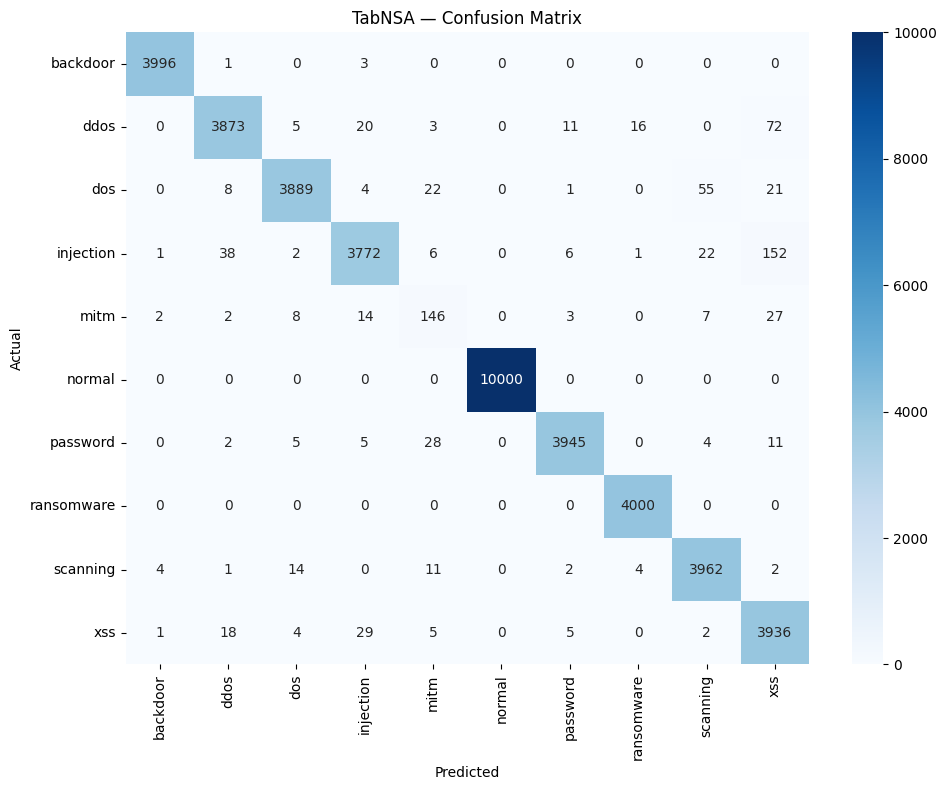

Saved: /content/drive/MyDrive/toniot_outputs/tabnsa_cm.png


In [9]:
# TabNSA TEST EVALUATION

test_ds = TensorDataset(torch.tensor(X_test_s), torch.tensor(y_test, dtype=torch.long))
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

t0 = time.time()
all_preds, all_true, all_proba = [], [], []
model.eval()
with torch.no_grad():
    for xb, yb in test_dl:
        logits = model(xb.to(DEVICE))
        proba  = F.softmax(logits, dim=-1).cpu().numpy()
        preds  = logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds); all_true.extend(yb.numpy())
        all_proba.append(proba)

infer_time = time.time() - t0
tabnsa_preds = np.array(all_preds)
tabnsa_proba = np.concatenate(all_proba, axis=0)

print(f"Inference time : {infer_time:.2f}s for {len(X_test_s):,} samples")
print(f"                ({infer_time / len(X_test_s) * 1000:.4f} ms per sample)")

tabnsa_results = evaluate(
    "TabNSA", y_test, tabnsa_preds,
    label_names=list(le.classes_), out_dir=DRIVE_OUT_DIR
)

  TABLE 1: TabNSA — Overall Evaluation Metrics
           Metric  Score
         Accuracy 0.9837
Precision (macro) 0.9510
   Recall (macro) 0.9542
       F1 (macro) 0.9524
    F1 (weighted) 0.9837
              MCC 0.9813
    Cohen's Kappa 0.9813
  ROC-AUC (macro) 0.9994



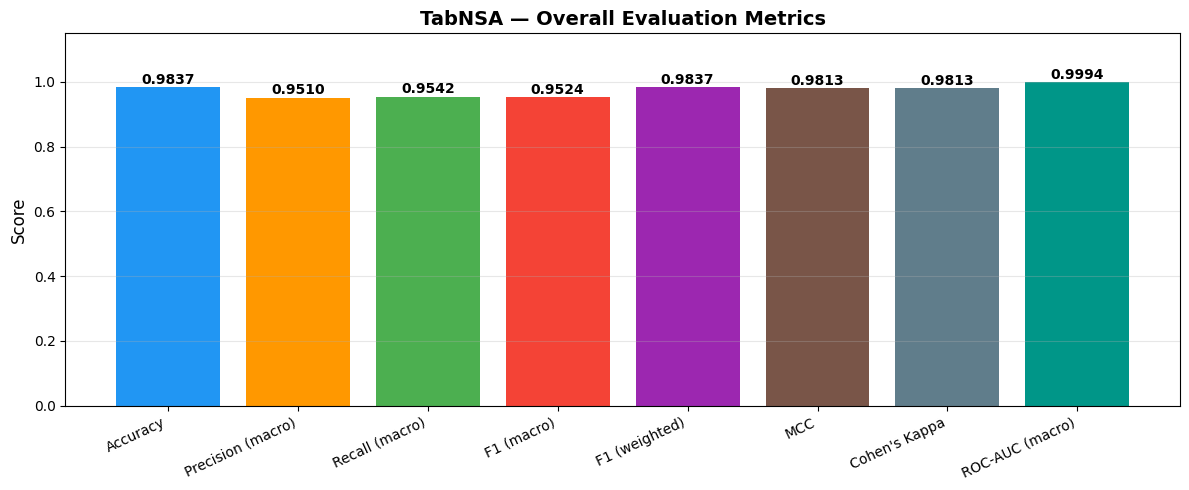

  TABLE 2: TabNSA — Per-Class Precision / Recall / F1
     Class  Precision  Recall  F1-Score  Support
  backdoor     0.9980  0.9990    0.9985     4000
      ddos     0.9822  0.9682    0.9752     4000
       dos     0.9903  0.9722    0.9812     4000
 injection     0.9805  0.9430    0.9614     4000
      mitm     0.6606  0.6986    0.6791      209
    normal     1.0000  1.0000    1.0000    10000
  password     0.9930  0.9862    0.9896     4000
ransomware     0.9948  1.0000    0.9974     4000
  scanning     0.9778  0.9905    0.9841     4000
       xss     0.9325  0.9840    0.9575     4000



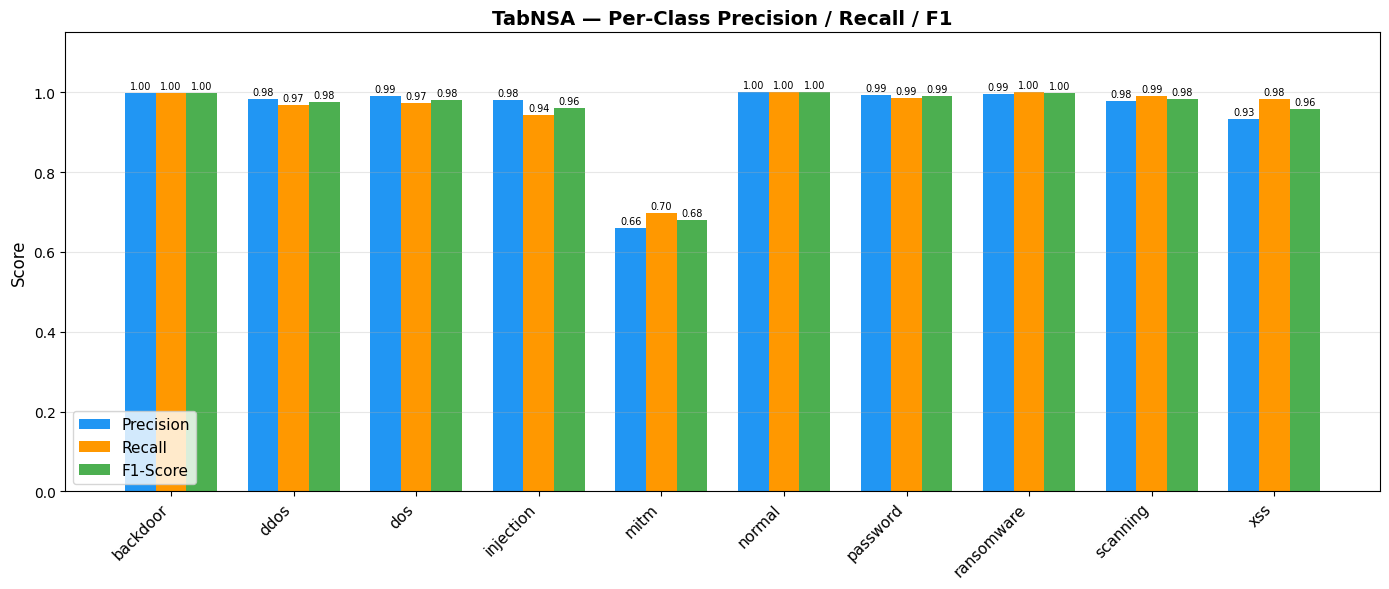

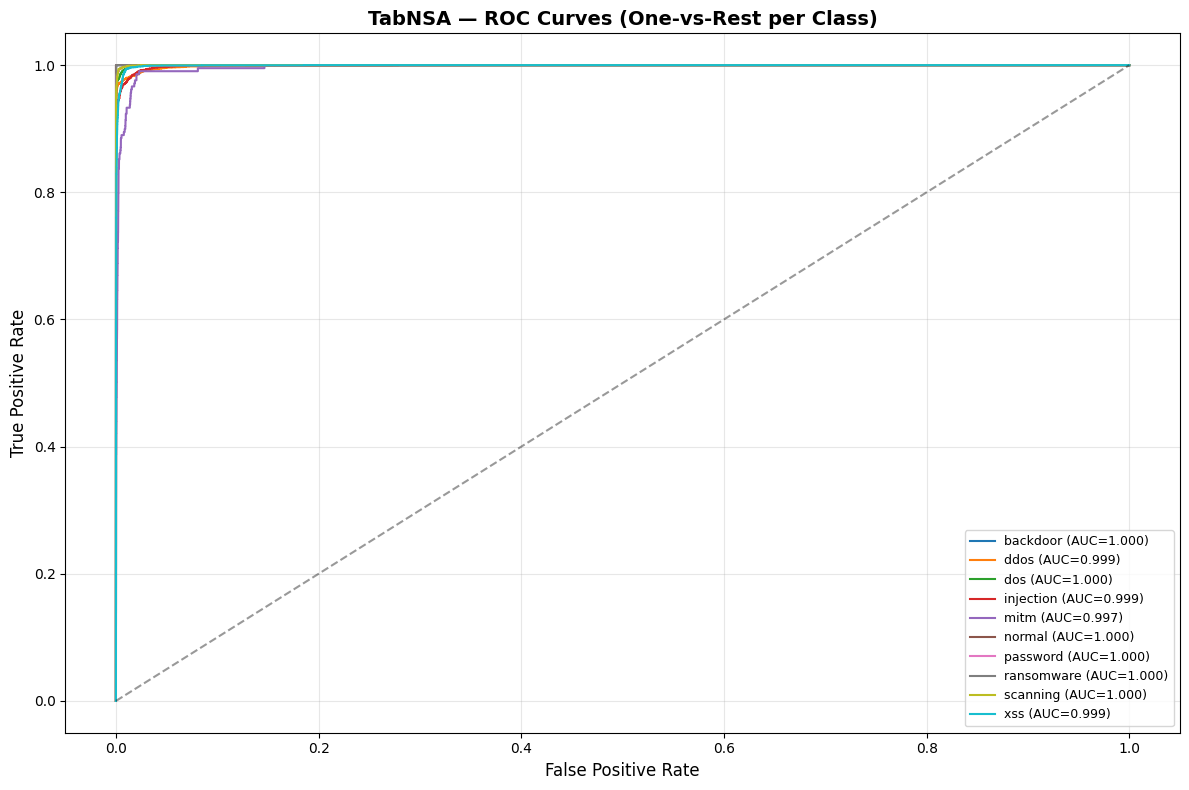

  TABLE 3: TabNSA — Per-Class ROC-AUC
     Class  ROC-AUC
  backdoor   1.0000
      ddos   0.9991
       dos   0.9998
 injection   0.9990
      mitm   0.9967
    normal   1.0000
  password   0.9999
ransomware   1.0000
  scanning   0.9999
       xss   0.9993

  Macro-average ROC-AUC: 0.9994

  TABLE 4: TabNSA — MCC & Cohen's Kappa
  MCC          : 0.9813 (Excellent)
  Cohen's Kappa: 0.9813 (Almost Perfect)


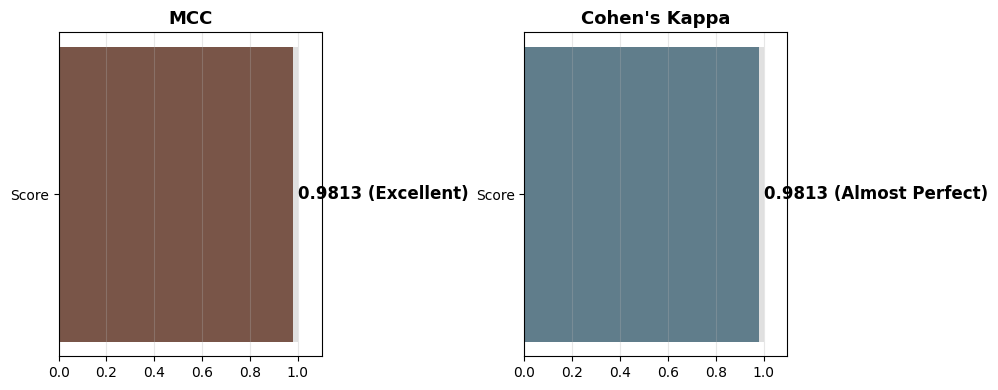

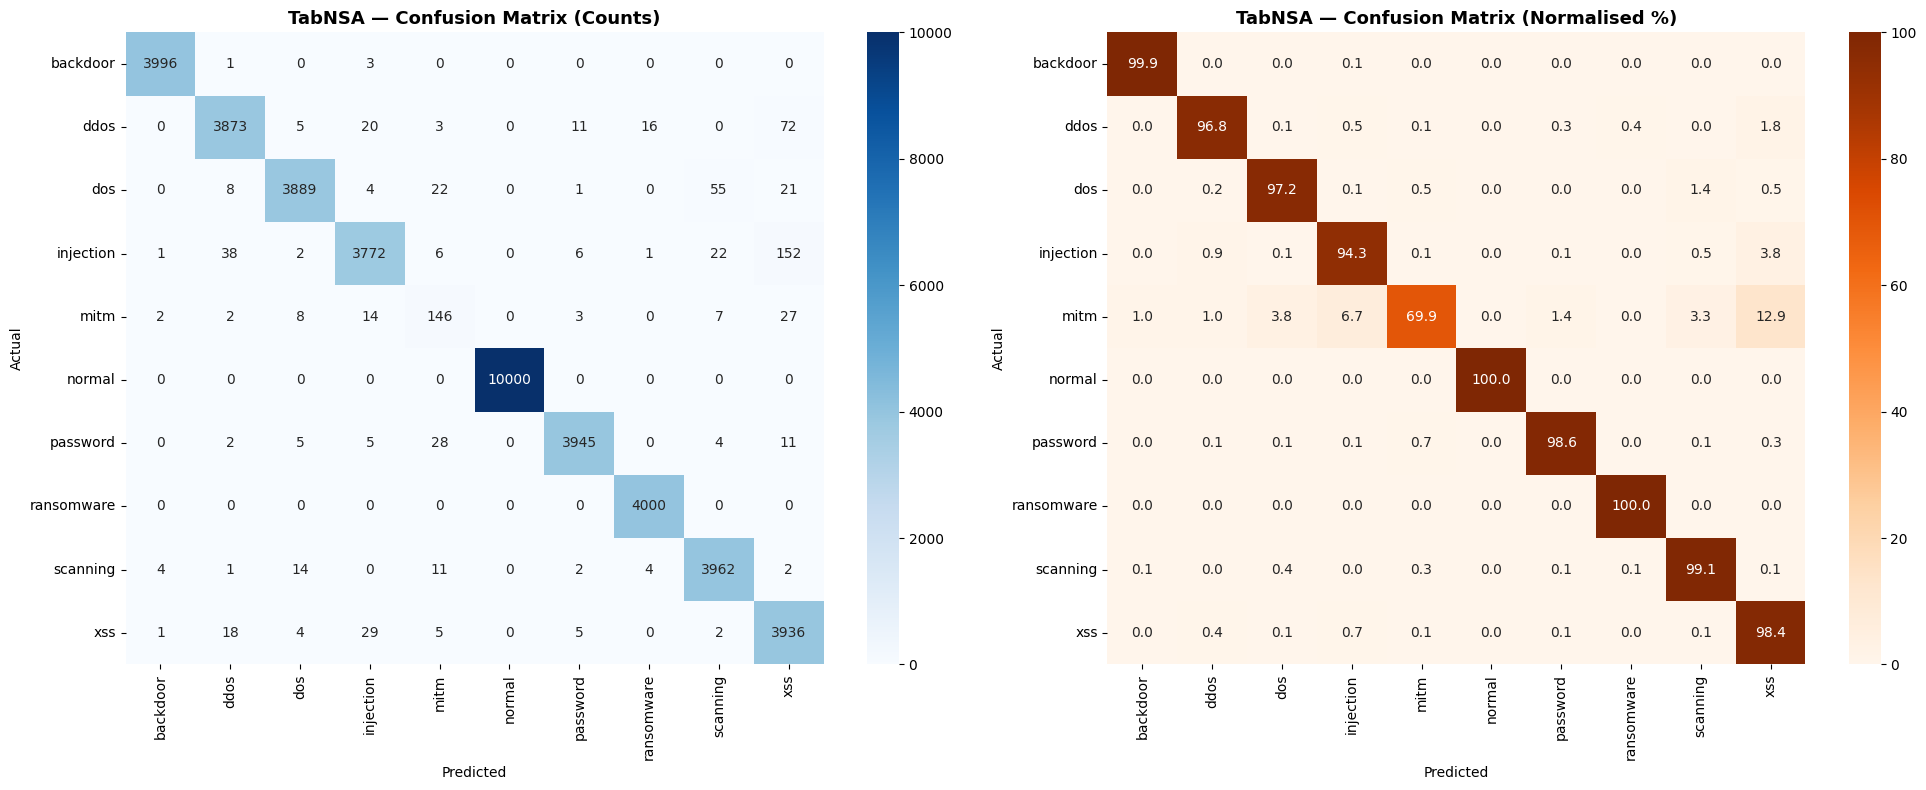


All visualisations saved to: /content/drive/MyDrive/toniot_outputs


In [10]:
# TABLES & VISUALISATIONS

y_true = y_test; y_pred = tabnsa_preds; y_prob = tabnsa_proba
label_names = list(le.classes_)

acc=accuracy_score(y_true,y_pred); prec_macro=precision_score(y_true,y_pred,average="macro",zero_division=0)
rec_macro=recall_score(y_true,y_pred,average="macro",zero_division=0)
f1_macro=f1_score(y_true,y_pred,average="macro",zero_division=0)
f1_weighted=f1_score(y_true,y_pred,average="weighted",zero_division=0)
mcc=matthews_corrcoef(y_true,y_pred); kappa=cohen_kappa_score(y_true,y_pred)
try: roc_auc=roc_auc_score(y_true,y_prob,multi_class="ovr",average="macro")
except: roc_auc=None

macro_df=pd.DataFrame({"Metric":["Accuracy","Precision (macro)","Recall (macro)","F1 (macro)","F1 (weighted)","MCC","Cohen's Kappa","ROC-AUC (macro)"],
"Score":[acc,prec_macro,rec_macro,f1_macro,f1_weighted,mcc,kappa,roc_auc if roc_auc else float('nan')]})
macro_df["Score"]=macro_df["Score"].round(4)
print("="*60); print("  TABLE 1: TabNSA — Overall Evaluation Metrics"); print("="*60)
print(macro_df.to_string(index=False)); print()

fig,ax=plt.subplots(figsize=(12,5))
colors=["#2196F3","#FF9800","#4CAF50","#F44336","#9C27B0","#795548","#607D8B","#009688"]
valid=macro_df.dropna(); bars=ax.bar(valid["Metric"],valid["Score"],color=colors[:len(valid)])
for bar,val in zip(bars,valid["Score"]): ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.01,f"{val:.4f}",ha="center",fontsize=10,fontweight="bold")
ax.set_ylim(0,1.15);ax.set_ylabel("Score",fontsize=12);ax.set_title("TabNSA — Overall Evaluation Metrics",fontsize=14,fontweight="bold")
ax.grid(axis="y",alpha=0.3);plt.xticks(rotation=25,ha="right");plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR,"tabnsa_macro_metrics.png"),dpi=150);plt.show()

prec_per=precision_score(y_true,y_pred,average=None,zero_division=0)
rec_per=recall_score(y_true,y_pred,average=None,zero_division=0)
f1_per=f1_score(y_true,y_pred,average=None,zero_division=0)
perclass_df=pd.DataFrame({"Class":label_names,"Precision":np.round(prec_per,4),"Recall":np.round(rec_per,4),"F1-Score":np.round(f1_per,4),"Support":[np.sum(y_true==c) for c in range(num_classes)]})
print("="*60);print("  TABLE 2: TabNSA — Per-Class Precision / Recall / F1");print("="*60)
print(perclass_df.to_string(index=False));print()

fig,ax=plt.subplots(figsize=(14,6));x=np.arange(len(label_names));w=0.25
b1=ax.bar(x-w,prec_per,w,label="Precision",color="#2196F3");b2=ax.bar(x,rec_per,w,label="Recall",color="#FF9800");b3=ax.bar(x+w,f1_per,w,label="F1-Score",color="#4CAF50")
for bars in[b1,b2,b3]:
 for bar in bars:
  h=bar.get_height()
  if h>0.01:ax.text(bar.get_x()+bar.get_width()/2,h+0.01,f"{h:.2f}",ha="center",fontsize=7)
ax.set_xticks(x);ax.set_xticklabels(label_names,rotation=45,ha="right",fontsize=11)
ax.set_ylim(0,1.15);ax.set_ylabel("Score",fontsize=12);ax.set_title("TabNSA — Per-Class Precision / Recall / F1",fontsize=14,fontweight="bold")
ax.legend(fontsize=11);ax.grid(axis="y",alpha=0.3);plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR,"tabnsa_perclass_prf.png"),dpi=150);plt.show()

y_true_bin=label_binarize(y_true,classes=list(range(num_classes)));auc_per_class=[]
fig,ax=plt.subplots(figsize=(12,8))
for i in range(num_classes):
 fpr,tpr,_=roc_curve(y_true_bin[:,i],y_prob[:,i]);class_auc=auc(fpr,tpr);auc_per_class.append(class_auc)
 ax.plot(fpr,tpr,label=f"{label_names[i]} (AUC={class_auc:.3f})")
ax.plot([0,1],[0,1],"k--",alpha=0.4);ax.set_xlabel("False Positive Rate",fontsize=12);ax.set_ylabel("True Positive Rate",fontsize=12)
ax.set_title("TabNSA — ROC Curves (One-vs-Rest per Class)",fontsize=14,fontweight="bold")
ax.legend(loc="lower right",fontsize=9);ax.grid(alpha=0.3);plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR,"tabnsa_roc_curves.png"),dpi=150);plt.show()
roc_df=pd.DataFrame({"Class":label_names,"ROC-AUC":np.round(auc_per_class,4)})
print("="*60);print("  TABLE 3: TabNSA — Per-Class ROC-AUC");print("="*60)
print(roc_df.to_string(index=False))
if roc_auc:print(f"\n  Macro-average ROC-AUC: {roc_auc:.4f}")

def interpret_mcc(v):
 if v>=0.9:return"Excellent"
 if v>=0.7:return"Strong"
 if v>=0.5:return"Moderate"
 if v>=0.3:return"Weak"
 return"Poor"
def interpret_kappa(v):
 if v>=0.81:return"Almost Perfect"
 if v>=0.61:return"Substantial"
 if v>=0.41:return"Moderate"
 if v>=0.21:return"Fair"
 return"Slight/Poor"
print();print("="*60);print("  TABLE 4: TabNSA — MCC & Cohen's Kappa");print("="*60)
print(f"  MCC          : {mcc:.4f} ({interpret_mcc(mcc)})")
print(f"  Cohen's Kappa: {kappa:.4f} ({interpret_kappa(kappa)})")

fig,axes=plt.subplots(1,2,figsize=(10,4))
for ax,mn,val,interp,col in[(axes[0],"MCC",mcc,interpret_mcc(mcc),"#795548"),(axes[1],"Cohen's Kappa",kappa,interpret_kappa(kappa),"#607D8B")]:
 ax.barh(["Score"],[val],color=col,height=0.4);ax.barh(["Score"],[1.0],color="#E0E0E0",height=0.4,zorder=0)
 ax.set_xlim(0,1.1);ax.text(val+0.02,0,f"{val:.4f} ({interp})",va="center",fontsize=12,fontweight="bold")
 ax.set_title(mn,fontsize=13,fontweight="bold");ax.grid(axis="x",alpha=0.3)
plt.tight_layout();plt.savefig(os.path.join(DRIVE_OUT_DIR,"tabnsa_mcc_kappa.png"),dpi=150);plt.show()

cm=confusion_matrix(y_true,y_pred);cm_norm=cm.astype('float')/cm.sum(axis=1,keepdims=True)*100
fig,axes=plt.subplots(1,2,figsize=(20,8))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=label_names,yticklabels=label_names,ax=axes[0])
axes[0].set_title("TabNSA — Confusion Matrix (Counts)",fontsize=13,fontweight="bold");axes[0].set_xlabel("Predicted");axes[0].set_ylabel("Actual")
sns.heatmap(cm_norm,annot=True,fmt=".1f",cmap="Oranges",xticklabels=label_names,yticklabels=label_names,ax=axes[1])
axes[1].set_title("TabNSA — Confusion Matrix (Normalised %)",fontsize=13,fontweight="bold");axes[1].set_xlabel("Predicted");axes[1].set_ylabel("Actual")
plt.tight_layout();plt.savefig(os.path.join(DRIVE_OUT_DIR,"tabnsa_cm_dual.png"),dpi=150);plt.show()
print("\nAll visualisations saved to:",DRIVE_OUT_DIR)

In [11]:
# OVERFITTING / UNDERFITTING DIAGNOSIS

all_preds_tr = []
model.eval()
with torch.no_grad():
    for xb, yb in train_dl:
        preds = model(xb.to(DEVICE)).argmax(dim=-1).cpu().numpy()
        all_preds_tr.extend(preds)

tabnsa_train_acc = accuracy_score(y_train, all_preds_tr)
tabnsa_train_f1  = f1_score(y_train, all_preds_tr, average="macro", zero_division=0)

print("=" * 50)
print("TabNSA — Train vs Test Diagnosis")
print("=" * 50)
print(f"  Train Acc    : {tabnsa_train_acc:.4f}")
print(f"  Test  Acc    : {tabnsa_results['accuracy']:.4f}")
print(f"  Train F1     : {tabnsa_train_f1:.4f}")
print(f"  Test  F1     : {tabnsa_results['f1_macro']:.4f}")
print()

acc_gap = tabnsa_train_acc - tabnsa_results['accuracy']
if acc_gap > 0.05:
    print(f"  Warning: Generalisation gap: {acc_gap:.4f} — possible overfitting")
elif tabnsa_results['accuracy'] < 0.80:
    print("  Warning: Low test accuracy — possible underfitting")
else:
    print(f"  Generalisation gap: {acc_gap:.4f} — model generalises well")

print(f"\n  Training time : {train_time:.1f}s")
print(f"  Inference time: {infer_time:.2f}s ({len(X_test_s):,} samples)")

TabNSA — Train vs Test Diagnosis
  Train Acc    : 0.1272
  Test  Acc    : 0.9837
  Train F1     : 0.0990
  Test  F1     : 0.9524

  Generalisation gap: -0.8565 — model generalises well

  Training time : 696.5s
  Inference time: 0.82s (42,209 samples)


In [12]:
# CELL 12 — SAVE RESULTS

results_df = pd.DataFrame([{
    "model"           : "TabNSA",
    "paper"           : "Neurocomputing 2026 — Eslamian & Sadeghi",
    "dataset"         : "TON-IoT Network",
    "train_samples"   : len(X_train),
    "test_samples"    : len(X_test_s),
    "n_features"      : n_features,
    "n_classes"       : num_classes,
    "accuracy"        : acc,
    "f1_macro"        : f1_macro,
    "f1_weighted"     : f1_weighted,
    "precision_macro" : prec_macro,
    "recall_macro"    : rec_macro,
    "mcc"             : mcc,
    "cohen_kappa"     : kappa,
    "roc_auc_macro"   : roc_auc,
    "train_acc"       : tabnsa_train_acc,
    "train_f1"        : tabnsa_train_f1,
    "train_time_s"    : round(train_time, 2),
    "infer_time_s"    : round(infer_time, 4),
}])

csv_path = os.path.join(DRIVE_OUT_DIR, "tabnsa_toniot_results.csv")
results_df.to_csv(csv_path, index=False)

print("\n========== FINAL RESULTS ==========")
print(results_df.T.to_string())
print(f"\nResults saved to: {csv_path}")


========== FINAL RESULTS ==========
                                                        0
model                                              TabNSA
paper            Neurocomputing 2026 — Eslamian & Sadeghi
dataset                                   TON-IoT Network
train_samples                                      147729
test_samples                                        42209
n_features                                             17
n_classes                                              10
accuracy                                         0.983653
f1_macro                                         0.952398
f1_weighted                                      0.983714
precision_macro                                  0.950971
recall_macro                                     0.954181
mcc                                              0.981281
cohen_kappa                                      0.981254
roc_auc_macro                                     0.99937
train_acc                          